In [91]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import torch
from torch import nn
import torch.optim
from torchinfo import summary


from collections import defaultdict
import config

from model_utils import train_test_split, FPLDataPipe, Trainer
from data_utils import sort_data, colors_config



In [92]:
data = pd.read_parquet(config.FPL_DATA_PATH)

In [93]:
data = sort_data(data)
data.head()

,second_name,first_name,team_name,web_name,match_id,player_code,gw,season_id,team_code,id,position,was_home,team_strength,status,form_lagged_1,goals_conceded_lagged_1,accurate_passes_ema_8,final_third_passes_lagged_1,ep_this_lagged_1,form_ema_8,duels_won_ema_8,transfers_in_event_ema_8,accurate_crosses_lagged_1,tackles_won_percent_ema_8,ep_next_lagged_1,aerial_duels_won_ema_8,successful_dribbles_percent_ema_8,successful_dribbles_lagged_1,dribbled_past_ema_8,event_points_ema_8,blocks_lagged_1,xg_per_90_ema_8,transfers_in_event_lagged_1,xgot_ema_8,shots_on_target_lagged_1,ground_duels_won_lagged_1,touches_opposition_box_lagged_1,accurate_long_balls_percent_ema_8,xgot_faced_lagged_1,selected_by_percent_ema_8,high_claim_lagged_1,value_form_lagged_1,shots_on_target_ema_8,transfers_out_event_lagged_1,big_chances_missed_ema_8,saves_lagged_1,gk_accurate_long_balls_lagged_1,assists_ema_8,transfers_out_event_ema_8,goals_prevented_ema_8,transfers_out,accurate_long_balls_ema_8,headed_clearances_ema_8,penalties_missed_lagged_1,value_form_ema_8,accurate_long_balls_lagged_1,successful_dribbles_ema_8,chance_of_playing_next_round_ema_8,interceptions_ema_8,bps_lagged_1,start_min_ema_8,goals_ema_8,team_goals_conceded_lagged_1,was_fouled_ema_8,xa_per_90_ema_8,duels_lost_ema_8,offsides_lagged_1,ep_this,expected_assists_ema_8,recoveries_ema_8,value_season_lagged_1,aerial_duels_won_lagged_1,start_min_lagged_1,gk_accurate_long_balls_ema_8,ep_this_ema_8,xa_lagged_1,total_shots_ema_8,xg_ema_8,minutes_played_ema_8,touches_lagged_1,finish_min_ema_8,corners_and_indirect_freekicks_order_lagged_1,dribbled_past_lagged_1,was_fouled_lagged_1,chances_created_lagged_1,penalties_missed_ema_8,ict_index_ema_8,selected_by_percent,event_points,value_ratio_ema_8,now_cost_ema_8,fouls_committed_lagged_1,transfers_in_event,expected_goals_conceded_lagged_1,penalties_scored_ema_8,touches_opposition_box_ema_8,transfers_out_event,clearances_ema_8,sweeper_actions_lagged_1,chance_of_playing_next_round_lagged_1,accurate_passes_percent_ema_8,total_shots_lagged_1,xgot_faced_ema_8,bonus_lagged_1,ground_duels_won_ema_8,ground_duels_won_percent_ema_8,assists_lagged_1,team_goals_conceded_ema_8,saves_ema_8,sweeper_actions_ema_8,selected_rank_ema_8,cost_change_event_ema_8,touches_ema_8,goals_lagged_1,cost_change_event,tackles_ema_8,tackles_lagged_1,big_chances_missed_lagged_1,now_cost_rank_lagged_1,minutes_played_lagged_1,high_claim_ema_8,chances_created_ema_8,transfers_out_ema_8,accurate_crosses_percent_ema_8,transfers_in_lagged_1,expected_goal_involvements_per_90_ema_8,clearances_lagged_1,finish_min_lagged_1,duels_lost_lagged_1,cost_change_start_lagged_1,xa_ema_8,goals_prevented_lagged_1,final_third_passes_ema_8,fouls_committed_ema_8,accurate_passes_lagged_1,accurate_crosses_ema_8,direct_freekicks_order_ema_8,xg_lagged_1,blocks_ema_8,influence_lagged_1,headed_clearances_lagged_1,tackles_won_lagged_1,expected_goals_conceded_per_90_ema_8,offsides_ema_8,aerial_duels_won_percent_ema_8,tackles_won_ema_8,recoveries_lagged_1,ep_next,interceptions_lagged_1,gk_accurate_passes_ema_8,event_points_lagged_1,xgot_lagged_1,cost_change_event_lagged_1,duels_won_lagged_1,threat_lagged_1,dreamteam_count_ema_8,penalties_scored_lagged_1,penalties_order_lagged_1
0,Milner,James,Brighton,Milner,24-25-prem-everton-vs-brighton-&-hove-albion,15157,1,2425,36,134,MID,0,3,a,0.0,0,0.000000,0,0.0,0.000000,0.000000,0.000000,0,0.000000,0.0,0.0,0.000000,0,0.0,0.000000,0,0.000000,0,0.0,0,0,0,0.000000,0.0,0.0,0,0.0,0.000000,0,0.0,0,0,0.0,0.000000,0.0,421,0.000000,0.0,0,0.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0,0.000000,0.000000,0.000000,0,1.6,0.000000,0.000000,0.0,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0,0.0,0,0,0,0,0.0,0.000000,0.1,2,0.000000,0.0,0,513,0.0,0.0,0.000000,421,0.000000,0,0,0.000000,0,0.0,0,0.000000,0.000000,0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0,0,0.000000,0,0,0,0,0.0,0.000000,0.000000,0.000000,0,0.000000,0,0,0,0,0.000000,0.0,0.000000,0.0,0,0.000000,0.0,0.0,0.000000,0.0,0,0,0.000000,0.0,0.0,

In [94]:
data.shape

(20337, 158)

In [95]:
cols_map = colors_config.FEATURES_GROUP

In [96]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [97]:
cols_map.keys()

dict_keys(['target', 'cols_id', 'static_cols', 'order_cols', 'ratio_features', 'performance_cols', 'pre_game_cols'])

In [98]:
cols_map["static_cols"]

['status', 'position', 'was_home', 'team_strength']

In [99]:
cols_map["pre_game_cols"]

['selected_by_percent',
 'cost_change_event',
 'transfers_out',
 'transfers_in_event',
 'transfers_out_event',
 'ep_this',
 'ep_next']

In [100]:
num_cols = [c for c in data.columns if "ema" in c or "lagg" in c]
len(num_cols)

136

In [101]:
data[cols_map["pre_game_cols"]].head()

,selected_by_percent,cost_change_event,transfers_out,transfers_in_event,transfers_out_event,ep_this,ep_next
0,0.1,0,421,513,421,1.6,1.6
1,0.1,0,1548,1189,635,2.0,1.0
2,0.1,0,4535,472,1998,0.7,1.7
3,0.0,0,10991,0,0,0.0,0.0
4,0.1,0,20304,113,497,0.0,-0.5


In [102]:
BATCH_SIZE = 64
fpl_data_pipe = FPLDataPipe(num_cols=num_cols+cols_map["pre_game_cols"],
                            cat_cols = cols_map["static_cols"] ,
                            batch_size=BATCH_SIZE)

In [103]:
data_splits = train_test_split(data)
fpl_data_pipe.prepare_data(**data_splits)

In [104]:
train_dataloader, valid_dataloader, test_dataloader = fpl_data_pipe.get_dataloaders()

In [105]:
x, y = next(iter(train_dataloader))
x.shape, y.shape

(torch.Size([64, 159]), torch.Size([64, 1]))

In [106]:
class MLP(nn.Module):
    def __init__(self, input_size: int,
                 hidden_size1: int,
                 hidden_size2: int,
                 output_size: int):
        super(MLP, self).__init__()

        block1 = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size1),
            nn.Dropout(0.3)
        )
        block2 = nn.Sequential(
            nn.Linear(hidden_size1, hidden_size2),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size2),
            nn.Dropout(0.2)
        )
        block3 = nn.Sequential(
            nn.Linear(hidden_size2, output_size)
        )

        self.block_stack = nn.Sequential(
            block1,
            block2,
            block3
        )

    def forward(self, x):
        return self.block_stack(x)

In [107]:
data.shape

(20337, 158)

In [108]:
mlp = MLP(
    input_size=x.shape[1],
    hidden_size1=64,
    hidden_size2=32,
    output_size=1
).to(device)

In [109]:
summary(
    model=mlp,
    input_size=(BATCH_SIZE, x.shape[1]),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18

)

Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
MLP                                      [64, 159]          [64, 1]            --                 True
├─Sequential: 1-1                        [64, 159]          [64, 1]            --                 True
│    └─Sequential: 2-1                   [64, 159]          [64, 64]           --                 True
│    │    └─Linear: 3-1                  [64, 159]          [64, 64]           10,240             True
│    │    └─LeakyReLU: 3-2               [64, 64]           [64, 64]           --                 --
│    │    └─BatchNorm1d: 3-3             [64, 64]           [64, 64]           128                True
│    │    └─Dropout: 3-4                 [64, 64]           [64, 64]           --                 --
│    └─Sequential: 2-2                   [64, 64]           [64, 32]           --                 True
│    │    └─Linear: 3-5                  [64, 64]           [64, 32]    

In [110]:
learning_rate = 0.001
weight_decay = .05
loss_fn = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.AdamW(lr=learning_rate,
                            params=mlp.parameters(),
                            weight_decay=weight_decay)


In [111]:
trainer = Trainer(device=device,
                  tensor_shape=(len(train_dataloader.dataset), x.shape[1]),
                  random_state=77)

In [112]:
NUM_EPOCHS = 400
results, best_model = trainer.model_eval(train_dataloader=train_dataloader,
                             test_dataloader=valid_dataloader,
                             model=mlp,
                             num_epochs=NUM_EPOCHS,
                             optimizer=optimizer,
                             loss_fn=loss_fn,
                             tolerance=0.001,
                             patience=NUM_EPOCHS//10)

  0%|          | 0/400 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.8959 | Test Loss: 1.4426
Train MSE: 13.1798 | Test MSE: 9.3227
Train MAE: 2.3284 | Test MAE : 1.8377
Train R2 Adj: -0.5241 | Test R2 Adj: -0.0670
Epoch: 40 | Train Loss: 0.7427 | Test Loss: 0.9284
Train MSE: 3.0062 | Test MSE: 4.8630
Train MAE: 1.1063 | Test MAE : 1.3112
Train R2 Adj: 0.6524 | Test R2 Adj: 0.4434
Early stopping | No improvement since 40 epochs


In [113]:
results_frame = pd.DataFrame(results)
results_frame.tail()

,train_loss,test_loss,train_mse,test_mse,train_mae,test_mae,train_r2_adj,test_r2_adj
56,0.730265,0.946870,2.958674,4.838441,1.090792,1.320002,0.657869,0.446254
57,0.729213,0.905483,2.948705,4.916650,1.090430,1.282905,0.659022,0.437303
58,0.734293,0.961022,2.908344,4.712115,1.097013,1.337940,0.663689,0.460712
59,0.726945,0.928088,2.901056,4.588989,1.089287,1.298712,0.664532,0.474803
60,0.735996,0.959876,2.928600,5.321963,1.099652,1.338880,0.661347,0.390916


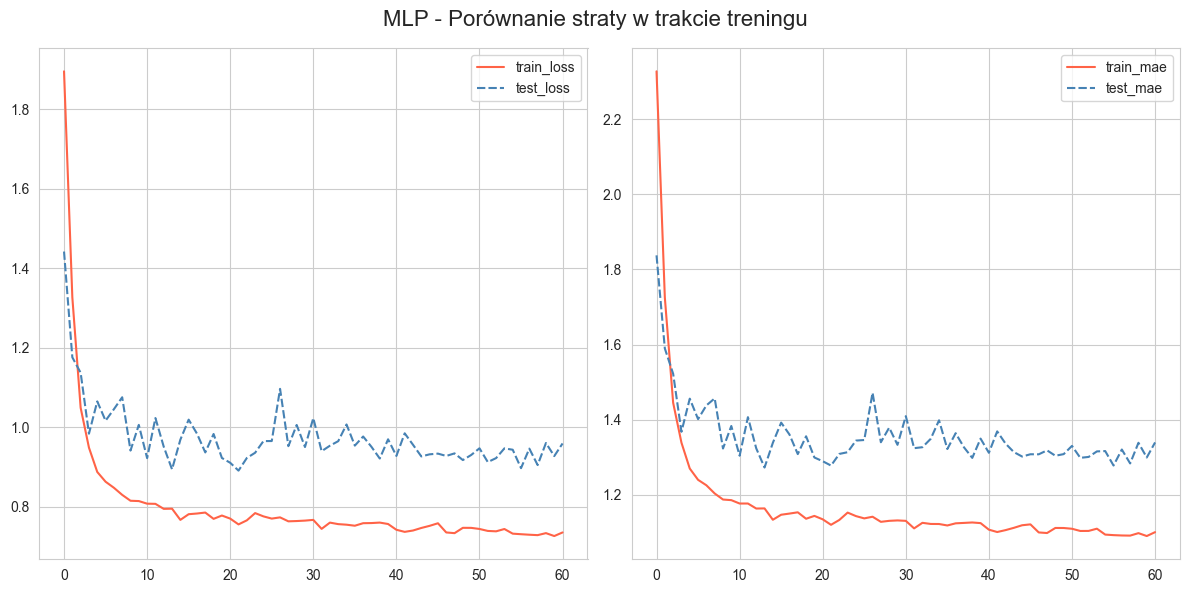

In [114]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.lineplot(results_frame[["train_loss", "test_loss"]],
             palette=["tomato", "steelblue"],
             ax=ax[0])
sns.lineplot(results_frame[["train_mae", "test_mae"]],
             palette=["tomato", "steelblue"],
             ax=ax[1])
fig.suptitle("MLP - Porównanie straty w trakcie treningu", fontsize=16)
plt.tight_layout()


In [115]:
mlp.load_state_dict(best_model)
mlp.eval()

MLP(
  (block_stack): Sequential(
    (0): Sequential(
      (0): Linear(in_features=159, out_features=64, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.3, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.2, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)

In [116]:
test_results = trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[0:3]

y_pred = trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[4]

In [117]:
y_test = data_splits["y_test"]

In [118]:
y_pred.shape, y_test.shape

(torch.Size([4305, 1]), (4305,))

In [119]:
preds = pd.DataFrame({
    "name" : data.loc[y_test.index, "web_name"],
    "y_true": y_test.values,
    "y_pred": y_pred.numpy().flatten()
})

In [120]:
preds.y_pred.max(), preds.y_true.max()

(np.float32(17.078897), np.int64(21))

In [128]:
players = data.loc[y_test.index, "web_name"].sample(8, random_state=2122)
players

18890         Baleba
13315         Ndiaye
6393        Kelleher
10117       Bissouma
1052            Gana
19218    Lucas Pires
4445          O'Nien
18269        O'Brien
Name: web_name, dtype: string

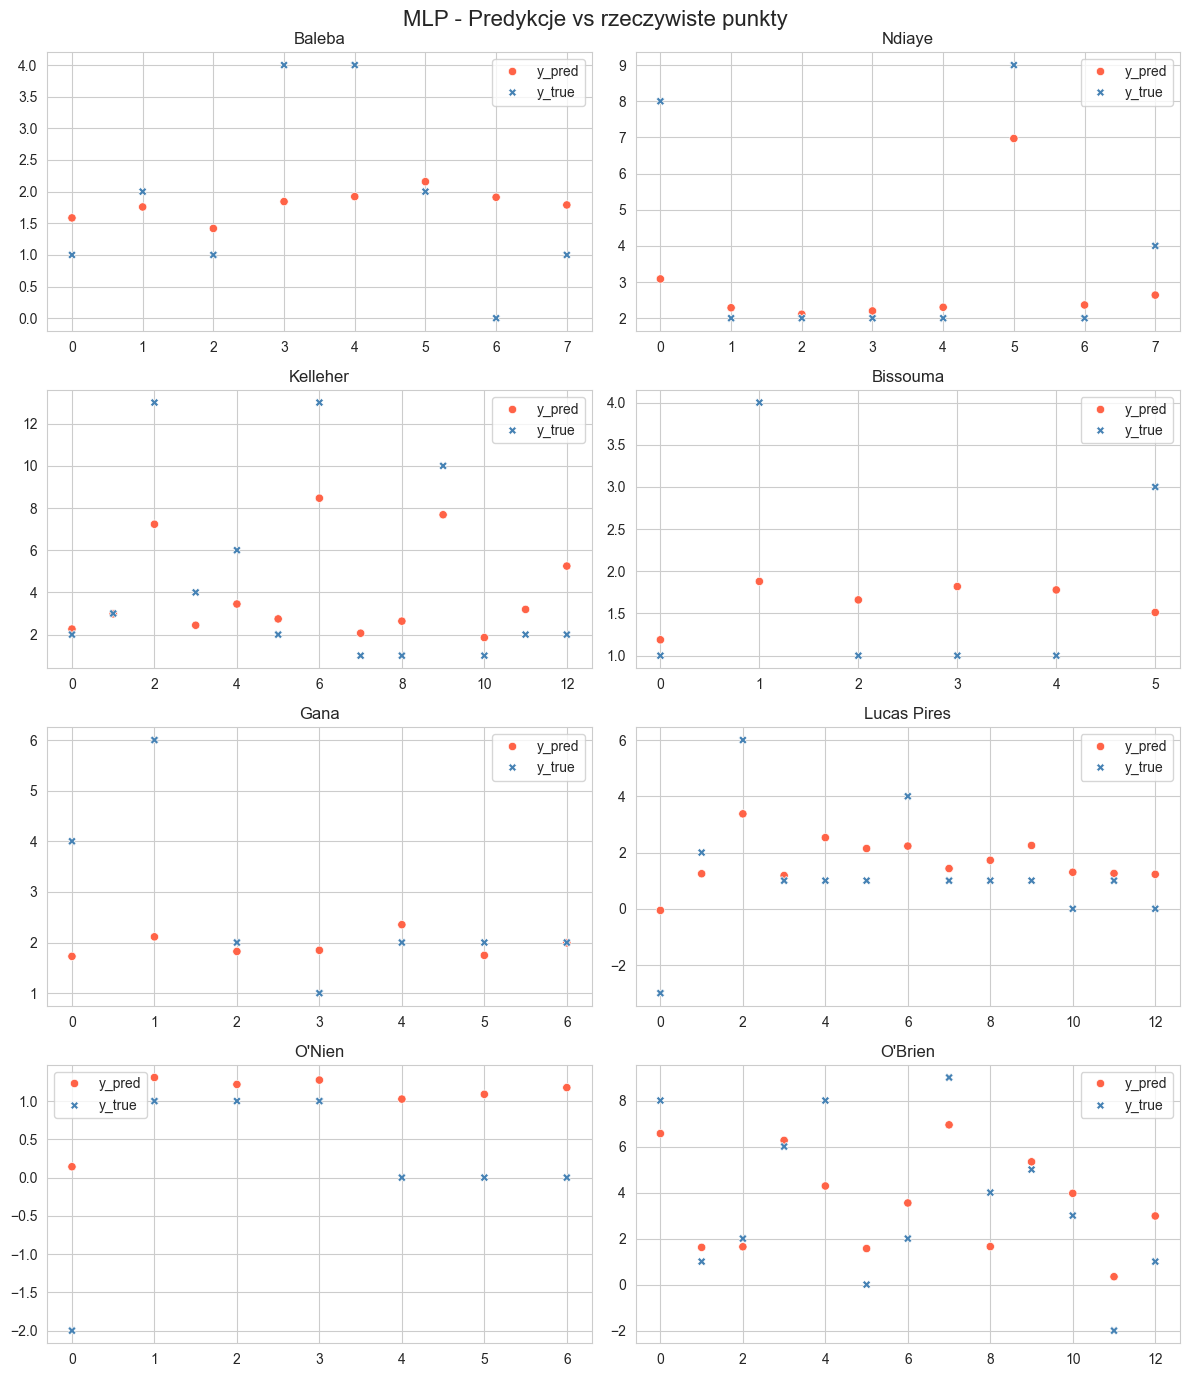

In [129]:
fig, ax = plt.subplots(nrows=4, ncols=len(players) // 4, figsize=(12, 14))
for i, player in enumerate(players):
    sns.scatterplot(data=preds.loc[preds.name==player, ["y_pred", "y_true"]].reset_index(drop=True),
                    palette=["tomato", "steelblue"], ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(player)
plt.suptitle("MLP - Predykcje vs rzeczywiste punkty", fontsize=16)
plt.tight_layout();
